In [ ]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms

In [48]:
with open("schaefer_parcel_counts.pkl", 'rb') as f:
    parcel_voxel_counts = pickle.load(f)
    
with open('/home/zachkaras/fmri_model/analysis/fir/schaefer_parcel_labels.pkl', 'rb') as f:
    schaefer_parcel_labels = pickle.load(f)
    
with open("/data/zachkaras/fmri_model_data/intermediate_results/all_results.pkl", 'rb') as f:
    records = pickle.load(f)

In [ ]:
"""
Overlapping Histogram — largest bar drawn first (behind), smaller bars in front.
For each bin, each layer draws from 0 to its own count (no stacking).
Accepts data as: {'label_1': [...], 'label_2': [...], ...}
Values should be integers in range 1-400.
"""


# ── Configuration ────────────────────────────────────────────────────────────

NUM_BINS = 200          # number of histogram bins
VALUE_MIN = 1          # minimum possible value in data
VALUE_MAX = 400        # maximum possible value in data
FIGSIZE = (14, 6)      # figure dimensions (width, height)
CHART_TITLE = "Group Distribution"

# ─────────────────────────────────────────────────────────────────────────────


def build_histogram(data: dict, num_bins: int, vmin: int, vmax: int) -> tuple:
    """
    Returns:
        bin_edges  : array of length num_bins + 1
        counts     : dict {label: array of length num_bins}
    """
    def calculate_voxel_proportion(num, idx):
        total_vx_count = parcel_voxel_counts[idx+1]
        proportion = num/total_vx_count
        return proportion

    bin_edges = np.linspace(vmin, vmax + 1, num_bins + 1)
    counts = {}
    for label, values in data.items():
        hist, _ = np.histogram(values, bins=bin_edges)
        ratios = [calculate_voxel_proportion(n, i) for i,n in enumerate(hist)]
        counts[label] = ratios
        # TODO I think these values can tell me about the distributions
    return bin_edges, counts

# TODO - instead, just add error bars indicating range of values across the layers

def plot_histogram(data: dict, num_bins: int = NUM_BINS,
                   vmin: int = VALUE_MIN, vmax: int = VALUE_MAX,
                   title: str = CHART_TITLE, figsize: tuple = FIGSIZE,
                   region_boundaries=None):
    """
    region_boundaries: list of (start_pos, end_pos, region_number) tuples.
      If provided, a horizontal line spans each region at two alternating
      offsets below the x-axis, with the region number centered on the line.
    """

    bin_edges, counts = build_histogram(data, num_bins, vmin, vmax)
    labels = list(counts.keys())
    n_bins = num_bins
    bin_width = bin_edges[1] - bin_edges[0]
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    sns.set_theme(style="ticks", context="talk")
    palette = sns.color_palette("rainbow", len(labels))

    sorted_labels = sorted(labels, key=lambda lbl: int(lbl.split("_")[-1]))
    label_color = {lbl: palette[i] for i, lbl in enumerate(sorted_labels)}

    fig, ax = plt.subplots(figsize=figsize)
    ax.grid(axis="y", linewidth=0.8, linestyle="--", zorder=0)
    ax.grid(axis="x", visible=False)

    # ── Per-bin overlapping bars ──────────────────────────────────────────────
    for b in range(n_bins):
        sorted_by_count = sorted(labels, key=lambda lbl: counts[lbl][b], reverse=True)
        sorted_by_count = sorted_by_count[:2]

        for lbl in sorted_by_count:
            val = counts[lbl][b]
            if val == 0:
                continue
            ax.bar(
                bin_centers[b],
                val,
                width=bin_width * 0.92,
                bottom=0,
                color=label_color[lbl],
                edgecolor="#2d2d4c",
                linewidth=0.4,
                zorder=2,
            )

    # ── Axes styling ──────────────────────────────────────────────────────────
    ax.set_title(title, fontsize=16, fontweight="bold", pad=16, loc="left")
    ax.set_xlabel("Cortical Region", color="#7070a0", fontsize=11, labelpad=45)
    ax.set_ylabel("Proportion of Top Voxels in Schaefer Parcel", color="#7070a0", fontsize=11, labelpad=8)
    ax.set_ylim([0.0, 1.0])
    ax.tick_params(axis='y', colors="#5a5a8a", labelsize=9)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # ── X-axis: horizontal region lines and numbers ───────────────────────────
    if region_boundaries is not None:
        ax.set_xticks([])

        # x in data coords, y in axes fraction (0 = plot bottom)
        base_trans = ax.get_xaxis_transform()
        # Two alternating y-offsets in points
        line_offsets_pts = [-5, -25]
        num_offsets_pts  = [-10, -31]

        for i, (start, end, num) in enumerate(region_boundaries):
            line_y = line_offsets_pts[i % 2]
            num_y  = num_offsets_pts[i % 2]
            mid    = (start + end + 1) / 2

            # Horizontal line spanning the region
            line_trans = mtransforms.offset_copy(base_trans, fig=fig, x=0, y=line_y, units='points')
            ax.plot([start, end + 1], [0, 0], color="#5a5a8a", linewidth=1,
                    transform=line_trans, clip_on=False)

            # Region number centered on the line
            ax.annotate(
                str(num),
                xy=(mid, 0), xycoords=('data', 'axes fraction'),
                xytext=(0, num_y), textcoords='offset points',
                ha='center', va='top', fontsize=10, color="#5a5a8a",
                clip_on=False,
            )
    else:
        tick_step = max(1, n_bins // 8)
        tick_positions = bin_edges[::tick_step]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels([f"{int(v)}" for v in tick_positions], color="#5a5a8a")
        ax.tick_params(axis='x', colors="#5a5a8a", labelsize=9)

    # ── Legend (in sorted layer order) ───────────────────────────────────────
    legend_patches = [
        mpatches.Patch(color=label_color[lbl], label=lbl)
        for lbl in sorted_labels
    ]
    ax.legend(
        handles=legend_patches,
        loc="best",
        frameon=True,
        framealpha=0.15,
        edgecolor="#2a2a4a",
        fontsize=9,
        ncol=2,
    )

    plt.tight_layout()
    plt.savefig(f"/data/zachkaras/fmri_model_data/plots/parcel_proportions-{title}.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()


In [5]:

def compute_region_boundaries(hemi_order, parcel_labels):
    """
    Returns a list of (start_pos, end_pos, region_number) tuples,
    one per unique HO cortical region, in the order they appear on the x-axis.
    """
    boundaries = []
    current_region = None
    start_pos = 0
    region_num = 1
    for i, p in enumerate(hemi_order):
        region = parcel_labels[p]
        if region != current_region:
            if current_region is not None:
                boundaries.append((start_pos, i - 1, region_num))
                region_num += 1
            current_region = region
            start_pos = i
    boundaries.append((start_pos, len(hemi_order) - 1, region_num))
    return boundaries

def plot_top_parcels(top_parcels, participant, model):
    for hemi in ['left', 'right']:
        hemi_order = list(schaefer_parcel_labels[hemi].keys())

        # Sorting the schaefer parcels so they align with the regions in the Harvard-Oxford atlas
        pos_map = {p: i for i, p in enumerate(hemi_order)}

        remapped = {
            layer: [pos_map[v] for v in vals if v in pos_map]
            for layer, vals in top_parcels.items()
        }

        region_boundaries = compute_region_boundaries(hemi_order, schaefer_parcel_labels[hemi])

        # Print the region number → name mapping for reference
        region_names = {}
        current_region = None
        region_num = 1
        for p in hemi_order:
            region = schaefer_parcel_labels[hemi][p]
            if region != current_region:
                region_names[region_num] = region
                current_region = region
                region_num += 1

        plot_histogram(remapped, num_bins=len(hemi_order), vmin=0, vmax=len(hemi_order) - 1,
                    title=f"{participant}-{model}-{hemi}_hemisphere", region_boundaries=region_boundaries)

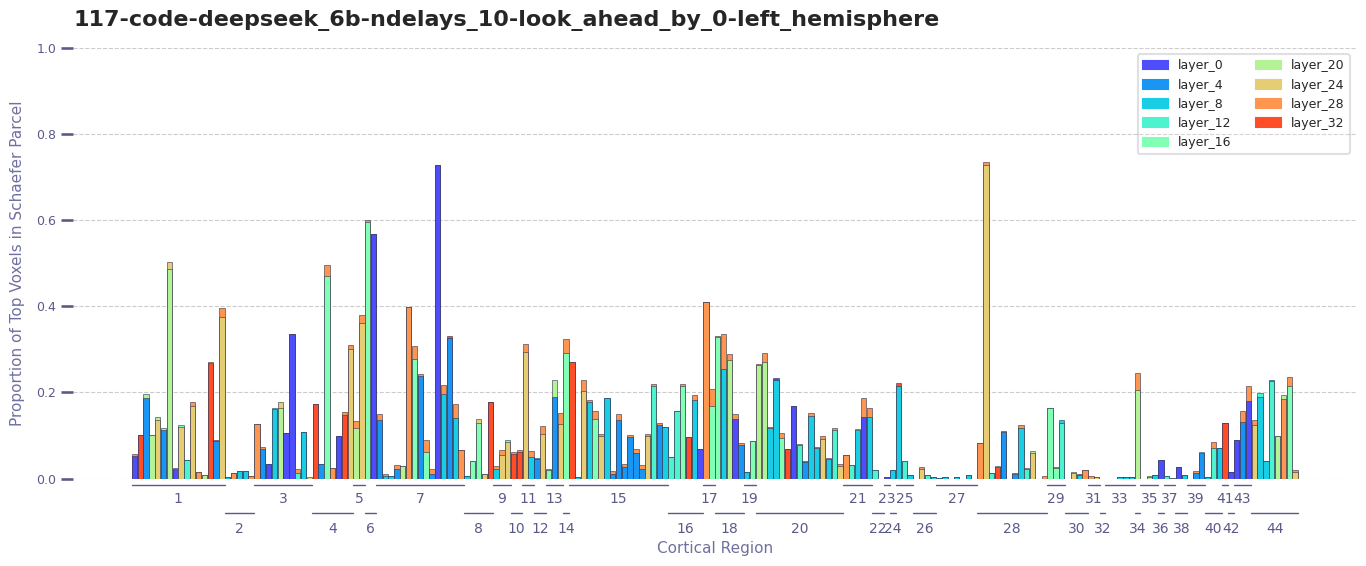

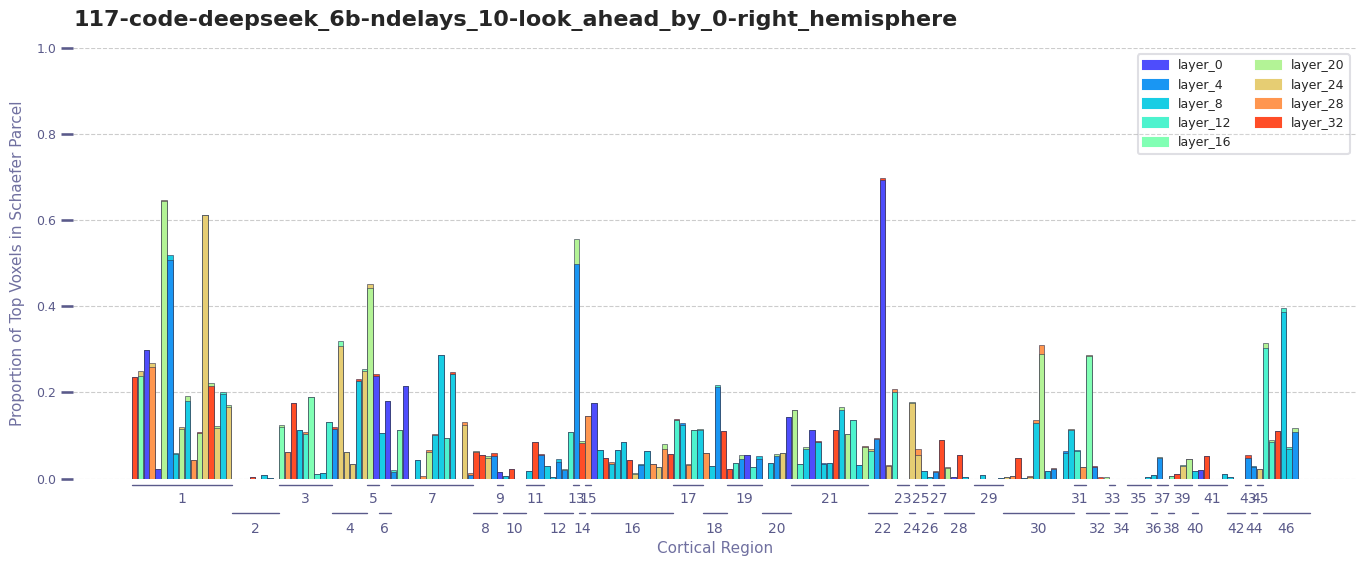

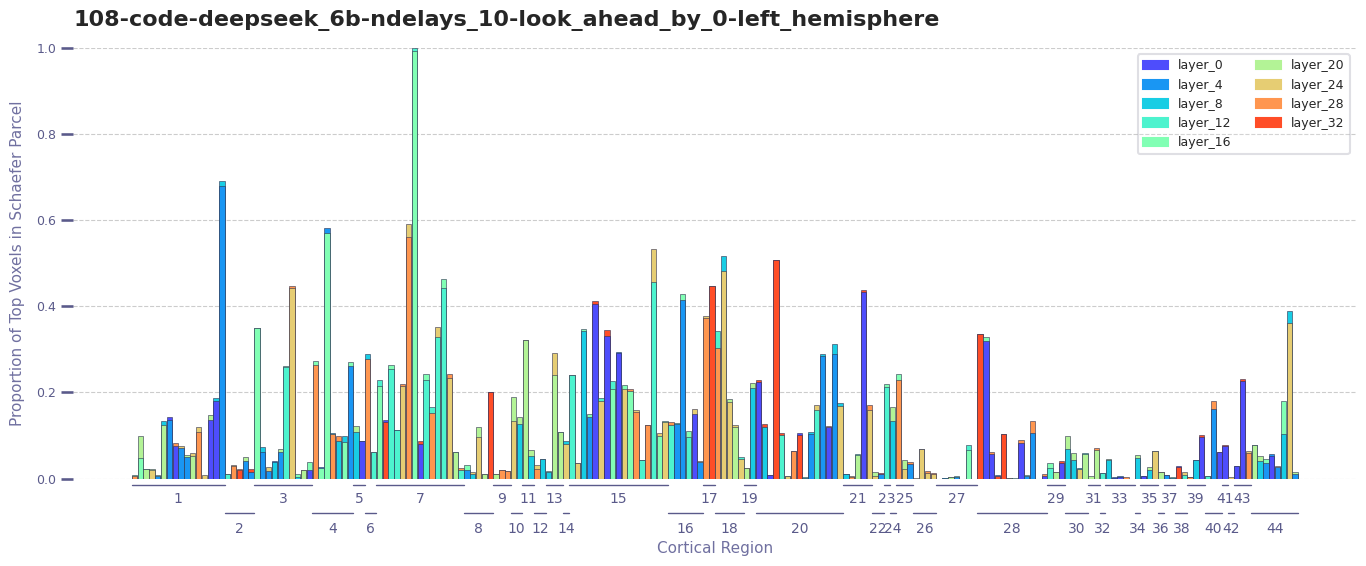

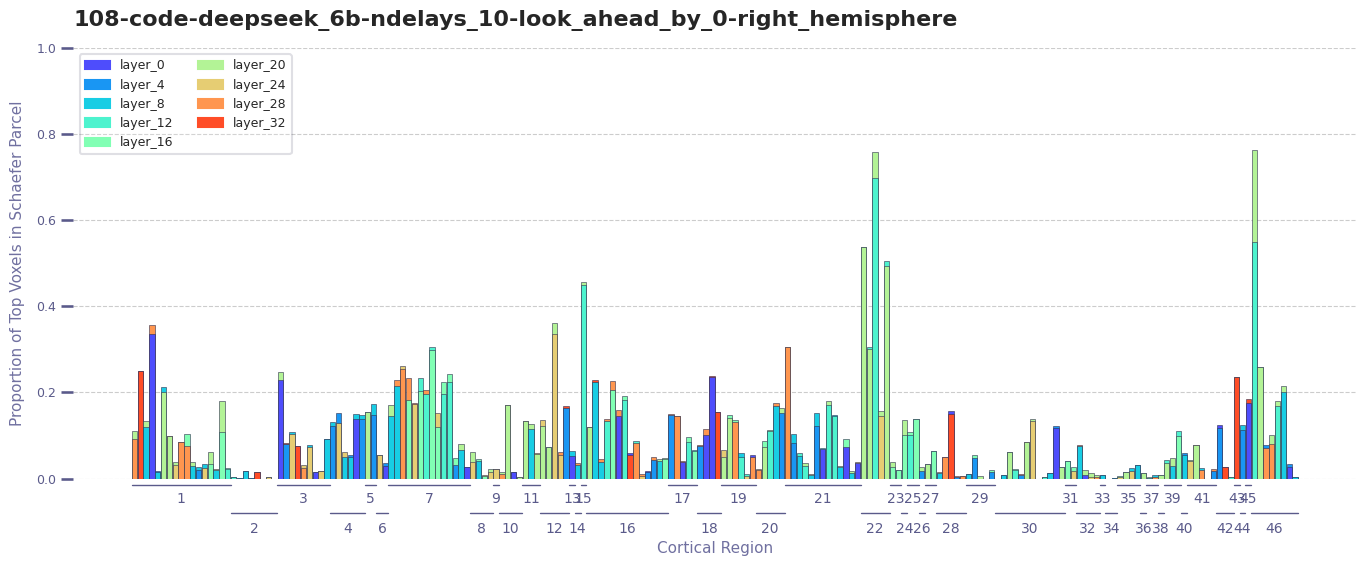

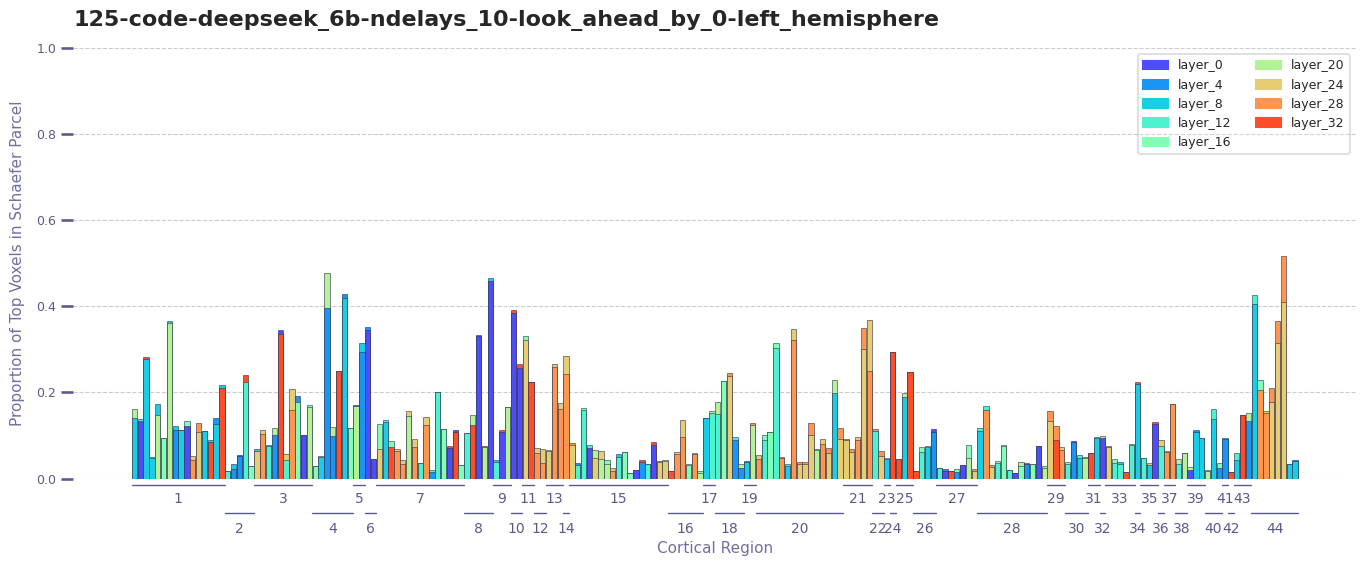

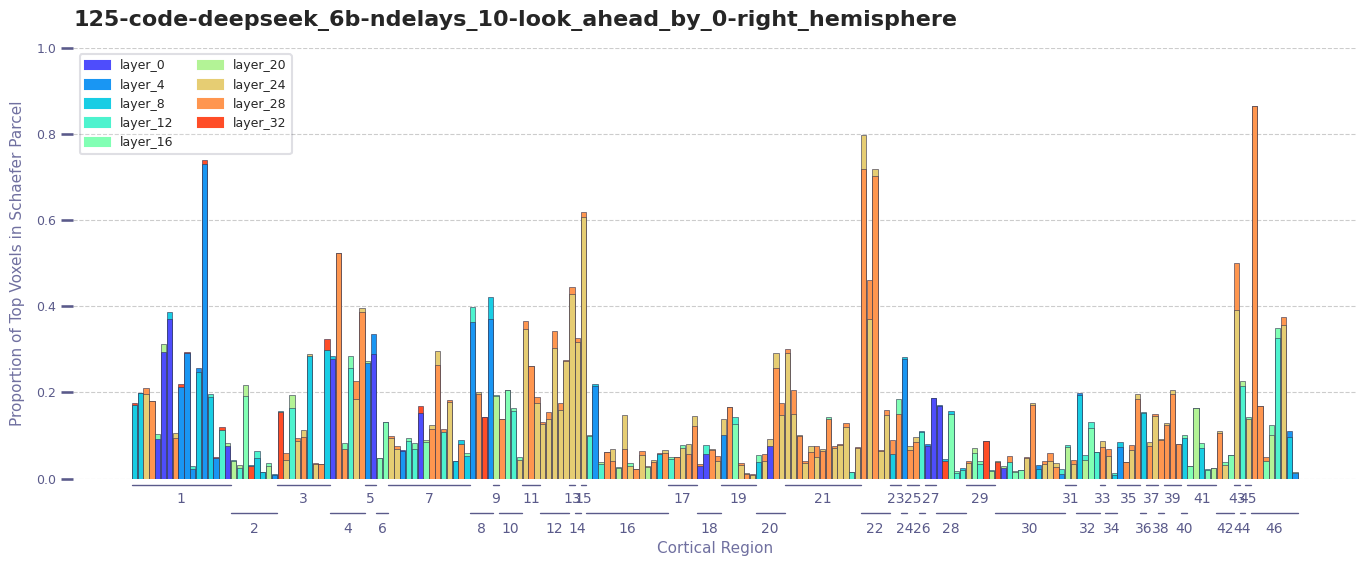

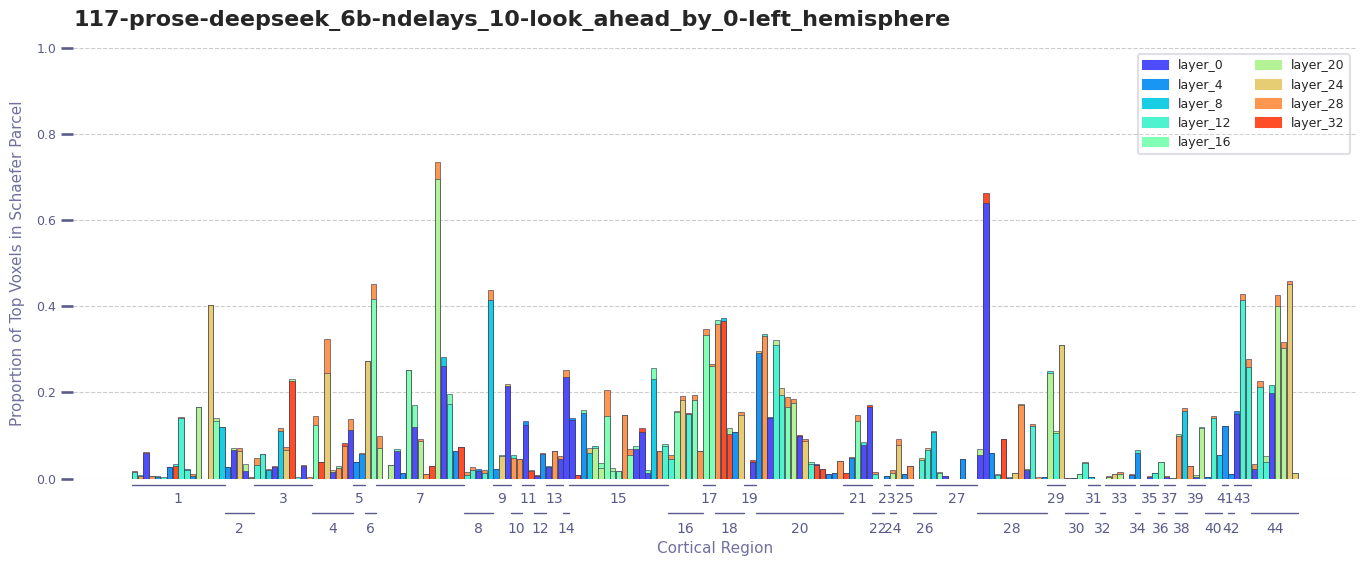

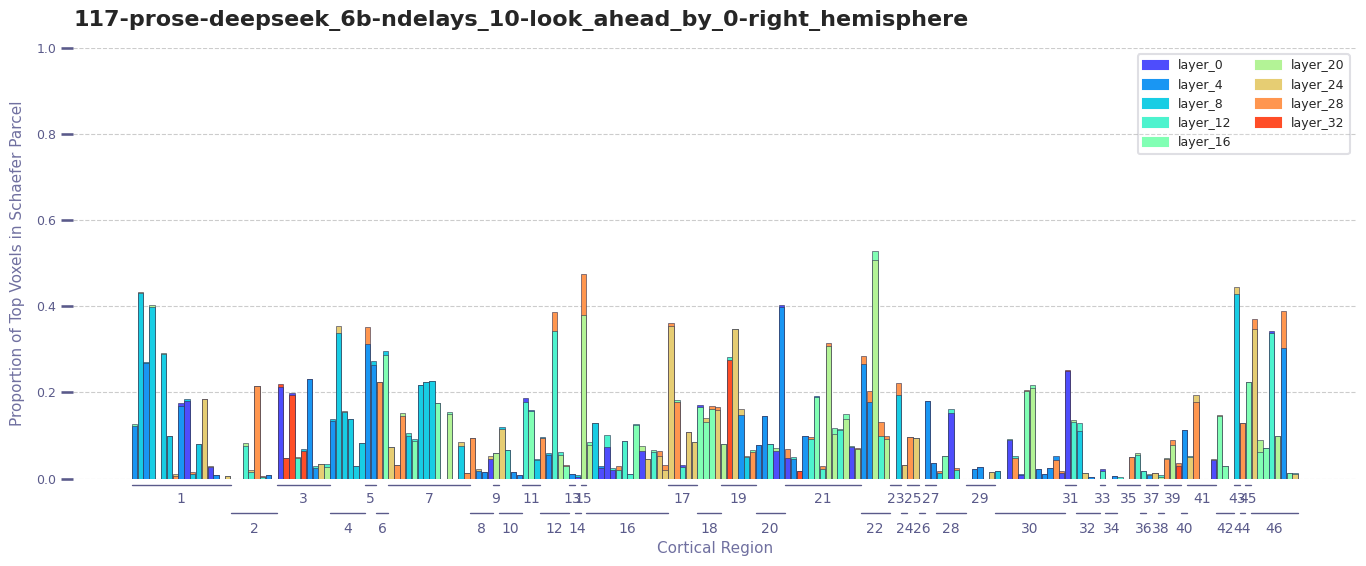

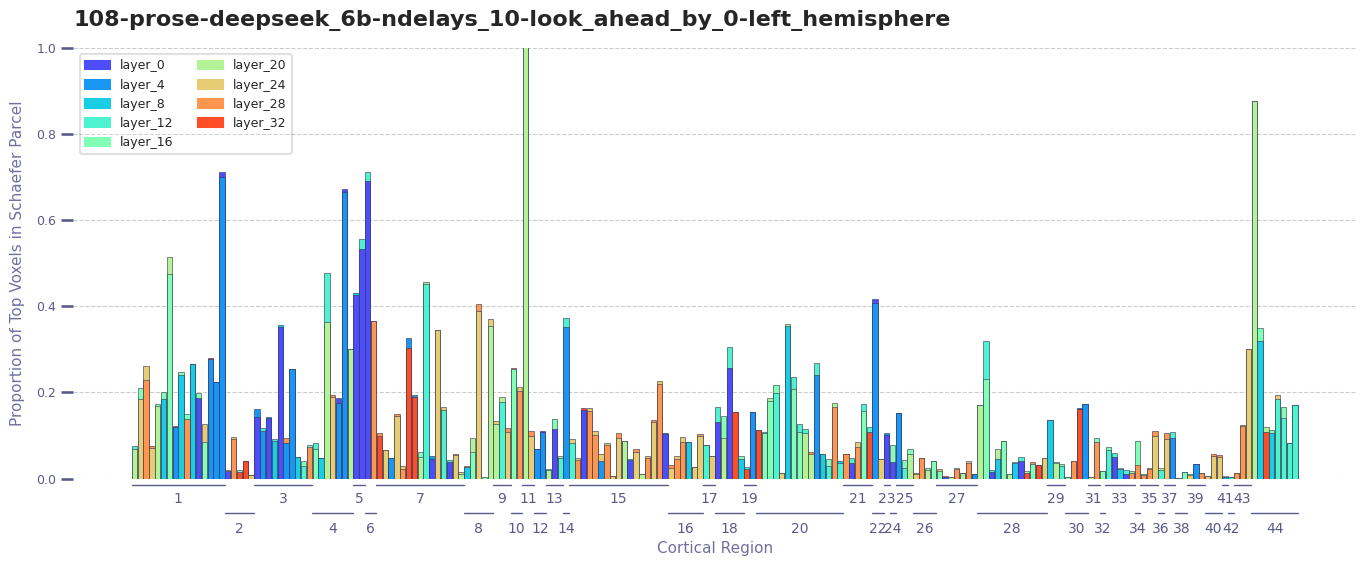

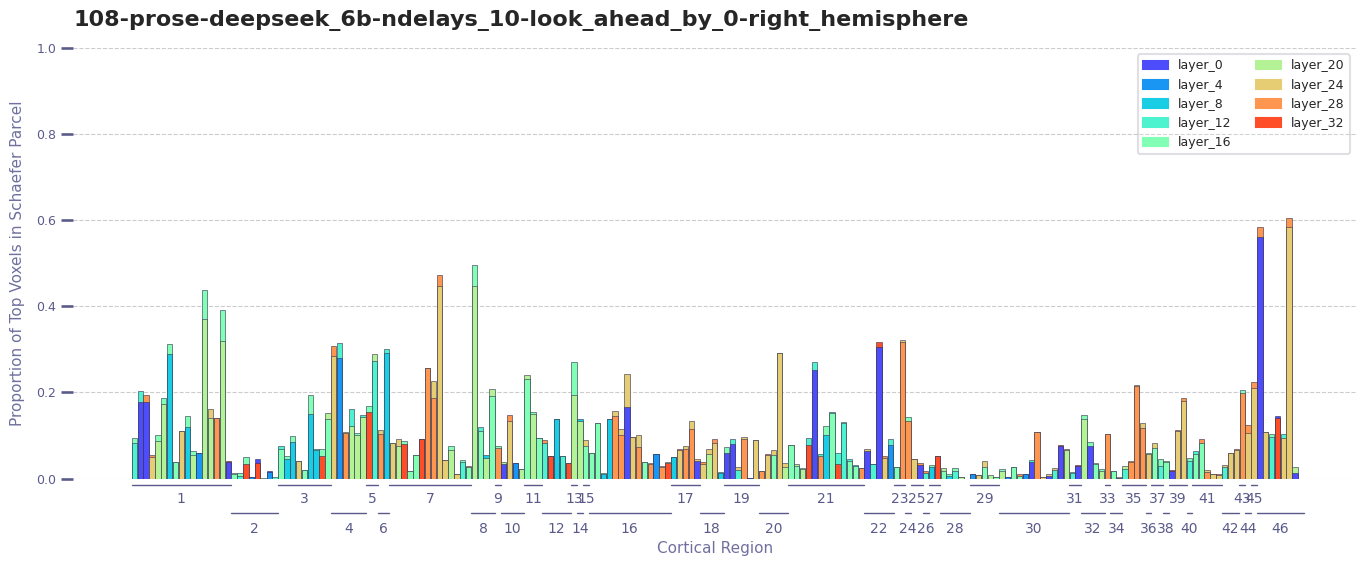

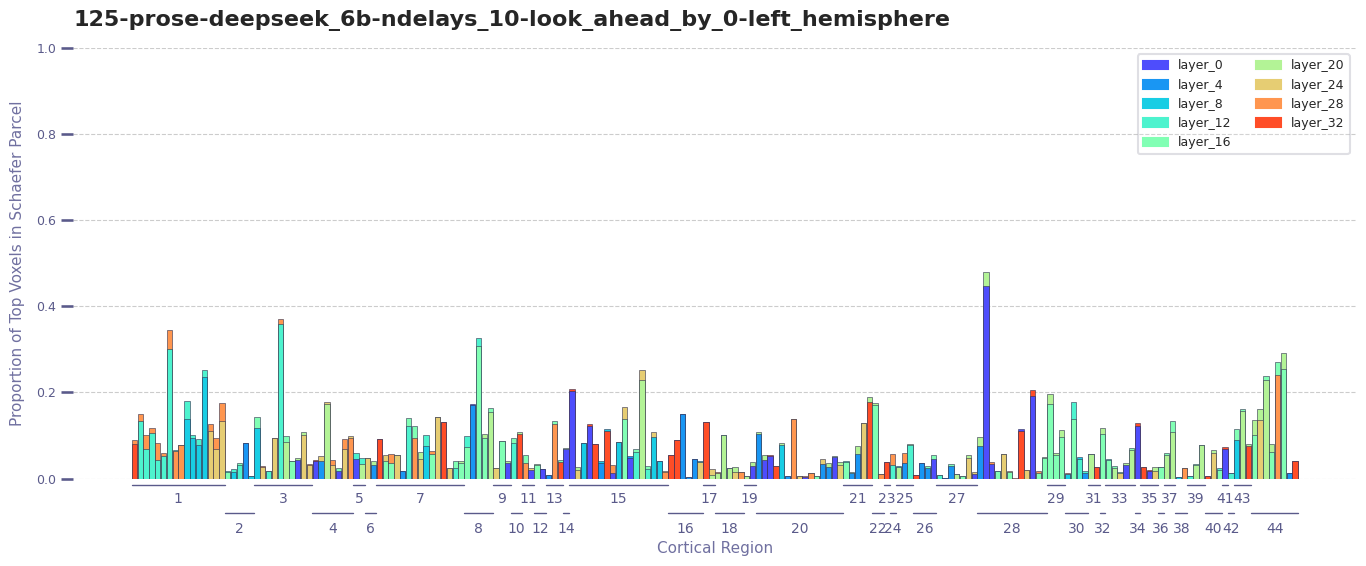

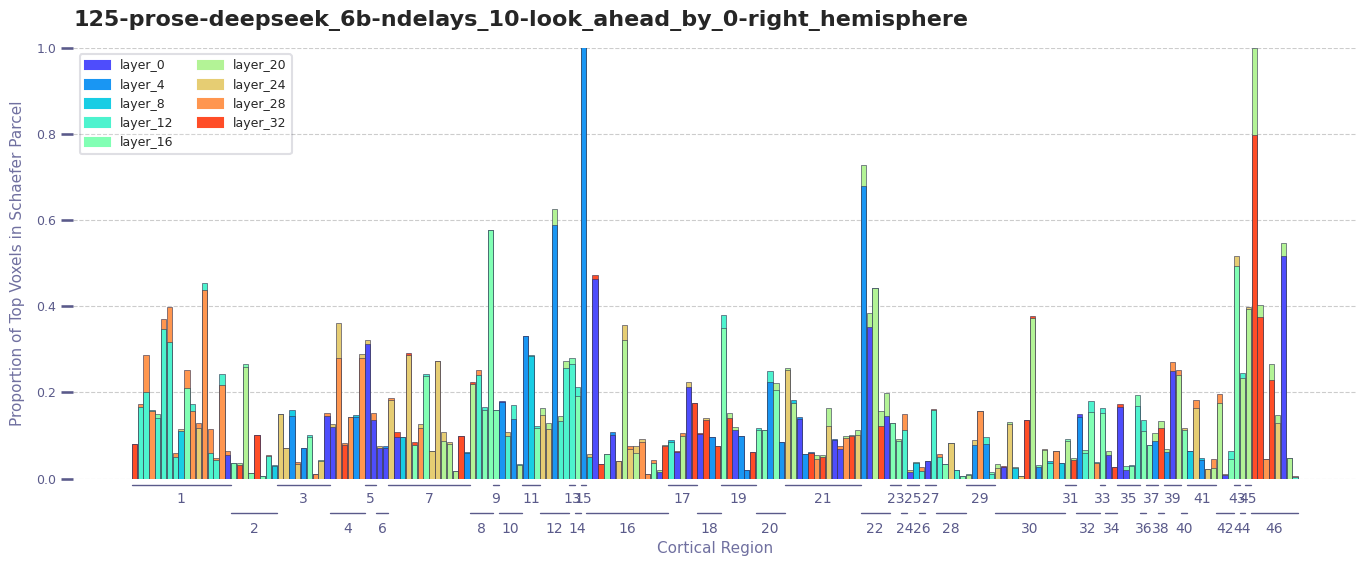

In [6]:
best_models = [
                # 'code-deepseek_6b-ndelays_4-look_ahead_by_10', 
                'code-deepseek_6b-ndelays_10-look_ahead_by_0',
                'prose-deepseek_6b-ndelays_10-look_ahead_by_0',
            #    'code-codegemma_7b-ndelays_4-look_ahead_by_10',
            #    'code-codegemma_7b-ndelays_16-look_ahead_by_0', 
                # 'prose-deepseek_6b-ndelays_4-look_ahead_by_10' # not as good of performance, but keeps parameters consistent
            #    'prose-codegemma_7b-ndelays_10-look_ahead_by_5', 
            #    'prose-deepseek_6b-ndelays_20-look_ahead_by_10'
            # 'prose-starcoder2_7b-ndelays_16-look_ahead_by_3'
            ]

key_participants = ['117', '108', '125']
for m in best_models:
    parts = m.split('-')
    task,model,delays,look_ahead = parts[0],parts[1],parts[2],parts[3]

    for vip in key_participants:
        filtered = records[(records['participant'] == vip) & 
                       (records['task']        == task) & 
                       (records['model']       == model) & 
                       (records['ndelays']     == delays) & 
                       (records['look_ahead']  == look_ahead)] # these also correspond to layers

        top_parcels = dict(zip(filtered['layer'], filtered['top_parcels']))
        top_parcels = {k:list(v) for k,v in top_parcels.items()}
        
        
        plot_top_parcels(top_parcels, vip, m)


In [7]:
# R code for brains below these graphs
# install.packages("remotes")
# remotes::install_github("LCBC-UiO/ggsegHO")
# library(ggseg)

# ggseg(atlas = hoCort, mapping = aes(fill = region)) +
#   scale_fill_brain("hoCort", package = "ggsegHO") +
#   theme(legend.position = "bottom",
#         legend.text = element_text(size = 6)) +
#   guides(fill = guide_legend(ncol = 2))

In [8]:
# TODO - test if parcel distributions is normal for participants



### Region counts

In [61]:
# inpath = '/data/zachkaras/fmri_model_data/intermediate_results' 
# with open(f"{inpath}/enrichment_analysis_results.pkl", 'rb') as f:
#     enriched_parcels = pickle.load(f)
    
# schaefer_labels = "schaefer_parcel_labels.pkl"
# with open(schaefer_labels, 'rb') as f:
#     region_labels = pickle.load(f)
# # records['top_parcels']
# # TODO - need to do this translation on the records

In [62]:
# important_participants = ['117', '125', '108']

# def translate_to_region_names(parcel_num, schaefer_labels):
#         parcel_num = int(parcel_num)
#         if parcel_num <= 200:
#             region = f"Left {schaefer_labels['left'][parcel_num]}"
#         else:
#             region = f"Right {schaefer_labels['right'][parcel_num]}"
#         return region

# def get_top_five_regions(parcel_dict):
#     return {region : val for i,(region,val) in enumerate(parcel_dict.items()) if i < 5}

# def plot_participant_parcels_across_layers(p, model, task, parcel_dict, region_colors):
#     # Build rows, sorting each layer's regions by score descending
#     rows = []
#     for _, row in parcel_dict.iterrows():
#         layer = str(row['layer'])
#         sorted_regions = sorted(row['top_five_regions'].items(), key=lambda x: x[1], reverse=True)[:5]
#         for rank, (region, val) in enumerate(sorted_regions):
#             rows.append({'layer': layer, 'region': region, 'score': val, 'rank': rank})
#     df = pd.DataFrame(rows)
#     print(df)

#     layers = sorted(df['layer'].unique(), key=lambda x: int(x.split('_')[1]))

#     n_bars = 5
#     bar_width = 0.15
#     gap = 0.3  # extra space between groups

#     fig, ax = plt.subplots(figsize=(14, 8))
#     group_centers = []

#     for g_idx, layer in enumerate(layers):
#         layer_df = df[df['layer'] == layer].sort_values('score', ascending=False)
#         n = len(layer_df)
#         offsets = np.arange(n) * bar_width - (n - 1) * bar_width / 2
#         center = g_idx * (n_bars * bar_width + gap)
#         group_centers.append(center)
#         for b_idx, (_, r) in enumerate(layer_df.iterrows()):
#             ax.bar(center + offsets[b_idx], r['score'], width=bar_width,
#                    color=region_colors[r['region']], edgecolor='black',
#                    label=r['region'])

#     # Deduplicated legend (first occurrence of each region)
#     handles, labels = ax.get_legend_handles_labels()
#     by_label = dict(zip(labels, handles))
#     ax.legend(by_label.values(), by_label.keys(), title="Region", loc='upper right', fontsize=10)

#     ax.set_xticks(group_centers)
#     ax.set_xticklabels(layers, rotation=45, ha='right')
#     ax.set_xlabel("Layer")
#     # ax.set_ylim([0, 25])
#     ax.set_ylabel("Top Regions")
#     ax.set_title(f"{p} - Top Regions Modeled Per Layer\n{model}")
#     plt.tight_layout()
#     plt.show()


In [63]:
# all_regions_global = set()
# for vip in important_participants:
#     mask = (records['participant'] == vip)
#     for (model, task), df in records[mask].groupby(['model', 'task']):
#         temp = df['top_parcels'].apply(lambda row: [translate_to_region_names(el, region_labels) for el in row])
#         df['top_HarvOx_regions'] = temp.apply(lambda row: dict(Counter(row)))
#         df['top_five_regions'] = df['top_HarvOx_regions'].apply(lambda row: get_top_five_regions(row))
#         for top_five in df['top_five_regions']:
#             all_regions_global.update(top_five.keys())

# all_regions_global = sorted(all_regions_global)  # sort for deterministic ordering
# palette = sns.color_palette("rainbow", len(all_regions_global))
# rng = np.random.default_rng(seed=1) # 111 is pretty good
# rng.shuffle(palette)
# region_colors = {r: palette[i] for i, r in enumerate(all_regions_global)}

In [64]:


# for vip in important_participants:
#     mask = (records['participant'] == vip)
#     for (model, task), df in records[mask].groupby(['model', 'task']):
#         temp = df['top_parcels'].apply(lambda row: [translate_to_region_names(el, region_labels) for el in row])
#         df['top_HarvOx_regions'] = temp.apply(lambda row: dict(Counter(row)))
#         df['top_five_regions'] = df['top_HarvOx_regions'].apply(lambda row: get_top_five_regions(row))
#         # df['top_five_regions'] = df['top_parcels'].apply(lambda row: get_top_five_regions(row))
#         filtered = df[['layer', 'top_five_regions']].copy()
#         filtered = filtered.sort_values('layer', key=lambda col: col.map(lambda x: int(x.split('_')[1])))

#         plot_participant_parcels_across_layers(vip, model, task, filtered, region_colors)
#         break
#     break

In [65]:
# Pre-compute a stable color mapping across all participants/models/tasks
# all_regions_global = set()
# for vip in important_participants:
#     mask = (enriched_parcels['participant'] == vip)
#     for (model, task), df in enriched_parcels[mask].groupby(['model', 'task']):
#         df['top_five_regions'] = df['enriched_region_names'].apply(lambda row: get_top_five_regions(row))
#         for top_five in df['top_five_regions']:
#             all_regions_global.update(top_five.keys())

# all_regions_global = sorted(all_regions_global)  # sort for deterministic ordering
# palette = sns.color_palette("rainbow", len(all_regions_global))
# rng = np.random.default_rng(seed=1) # 111 is pretty good
# rng.shuffle(palette)
# region_colors = {r: palette[i] for i, r in enumerate(all_regions_global)}

# for vip in important_participants:
#     mask = (enriched_parcels['participant'] == vip)
#     for (model, task), df in enriched_parcels[mask].groupby(['model', 'task']):
#         df['top_five_regions'] = df['enriched_region_names'].apply(lambda row: get_top_five_regions(row))
#         filtered = df[['layer', 'top_five_regions']].copy()
#         filtered = filtered.sort_values('layer', key=lambda col: col.map(lambda x: int(x.split('_')[1])))

#         plot_participant_parcels_across_layers(vip, model, task, filtered, region_colors)
#     #     break
#     # break

In [12]:
# TODO - measure degree of orthogonality between participants' predicted and recorded signals 

# Maybe I can use cosine similarity for this 
# 
